In [1]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

In [2]:
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

In [3]:
import os 

os.chdir("..")
print(os.getcwd())

e:\project_archive\new project


In [4]:
from pathlib import Path 

data_path = Path("data/raw")

if not data_path.exists():
    raise FileNotFoundError

In [5]:
student_data_path = data_path / "student_academic_data" / "data.csv"

if not student_data_path.exists():
    raise FileNotFoundError

In [6]:
df = pd.read_csv(student_data_path, sep=";")

In [7]:
# Clean up column names (strip whitespace/tabs)
df.columns = df.columns.str.strip().str.replace(r"\s+", " ", regex=True)

# Define target variable
target_col = "Target"

In [8]:
# Automatically identify numerical and categorical/discrete columns
# Based on unique value thresholds
unique_counts = df.drop(columns=[target_col]).nunique()
categorical_cols = unique_counts[unique_counts <= 10].index.tolist()
numerical_cols = unique_counts[unique_counts > 10].index.tolist()


In [9]:
print(f"Datset Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Numerical features ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical/Discreate feature ({len(categorical_cols)}): {categorical_cols}")

Datset Loaded: 4424 rows, 37 columns
Numerical features (22): ['Application mode', 'Course', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Age at enrollment', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)']
Categorical/Discreate feature (14): ['Marital status', 'Application order', 'Daytime/evening attendance', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International', 'Curricular units 2n

# 1. Dataset Overview

In [10]:
print("--- Shape ---")
display(df.shape)

print("----Head---")
display(df.head())

print("\n--- INFO ---")
df.info()

print("\n--- DESCRIPTIVE STATISTICS ---")
display(df.describe().T)


--- Shape ---


(4424, 37)

----Head---


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate



--- INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                

,count,mean,std,min,25%,50%,75%,max
Marital status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime/evening attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous qualification (grade),4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mother's qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Father's qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


In [10]:
print("--- MISSING VALUES ---")
missing_vals = df.isnull().sum()
print(missing_vals[missing_vals > 0] if missing_vals.sum() > 0 else "No missing values found.")

--- MISSING VALUES ---
No missing values found.


In [16]:
len(missing_vals[missing_vals > 0])

0

In [17]:
print("\n--- DUPLICATE ROWS ---")
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates.item()}")


--- DUPLICATE ROWS ---
Number of duplicate rows: 0


In [13]:
set(df["Target"].unique())

{'Dropout', 'Enrolled', 'Graduate'}

In [20]:
print("\n--- DATA TYPES CHECK ---")
print(df.dtypes)


--- DATA TYPES CHECK ---
Marital status                                      int64
Application mode                                    int64
Application order                                   int64
Course                                              int64
Daytime/evening attendance                          int64
Previous qualification                              int64
Previous qualification (grade)                    float64
Nacionality                                         int64
Mother's qualification                              int64
Father's qualification                              int64
Mother's occupation                                 int64
Father's occupation                                 int64
Admission grade                                   float64
Displaced                                           int64
Educational special needs                           int64
Debtor                                              int64
Tuition fees up to date                       

MATHEMATICAL OVERVIEW

In [13]:
# Encode target into numeric codes for machine learning/statistical math
df_encoded = df.copy()
le = LabelEncoder()
df_encoded[target_col] = le.fit_transform(df_encoded[target_col])

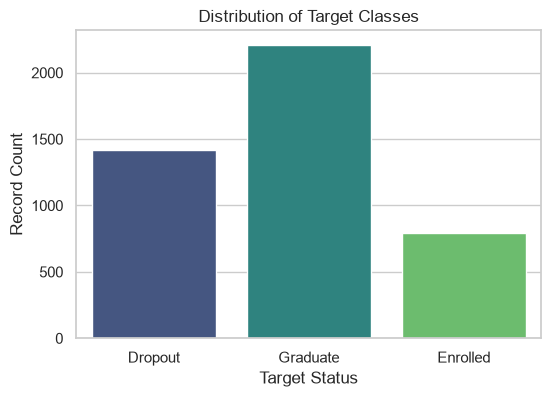

Target Class Breakdown (Percentage):
Target
Graduate    49.932188
Dropout     32.120253
Enrolled    17.947559
Name: proportion, dtype: float64


In [14]:
# 3. Target Variable Analysis

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=target_col, palette="viridis")
plt.title("Distribution of Target Classes")
plt.xlabel("Target Status")
plt.ylabel("Record Count")
plt.show()

print("Target Class Breakdown (Percentage):")
print(df[target_col].value_counts(normalize=True) * 100)

8. Statistical Analysis (Mathematical Screening Scout)
We run statistical screenings first to calculate pure mathematical significance across all attributes before plotting.

In [15]:

stat_features = []
p_values = []
test_used = []

# Screen all numerical columns using Kruskal-Wallis
for col in numerical_cols:
    groups = [group[1].values for group in df[col].groupby(df[target_col])]
    stat, p_val = stats.kruskal(*groups)
    stat_features.append(col)
    p_values.append(p_val)
    test_used.append("Kruskal-Wallis (Numerical)")

# Screen all categorical columns using Chi-Square Contingency Tests
for col in categorical_cols:
    contingency_table = pd.crosstab(df[col], df[target_col])
    chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)
    stat_features.append(col)
    p_values.append(p_val)
    test_used.append("Chi-Square (Categorical)")

stat_report = pd.DataFrame({
    "Feature": stat_features,
    "Test_Used": test_used,
    "p_value": p_values
})
stat_report["Is_Statistically_Significant"] = stat_report["p_value"] < 0.05
stat_report = stat_report.sort_values(by="p_value")

print("--- STATISTICAL SCREENING REPORT ---")
display(stat_report.head(15))



--- STATISTICAL SCREENING REPORT ---


,Feature,Test_Used,p_value,Is_Statistically_Significant
14,Curricular units 1st sem (approved),Kruskal-Wallis (Numerical),0.000000e+00,True
20,Curricular units 2nd sem (approved),Kruskal-Wallis (Numerical),0.000000e+00,True
21,Curricular units 2nd sem (grade),Kruskal-Wallis (Numerical),1.015147e-302,True
15,Curricular units 1st sem (grade),Kruskal-Wallis (Numerical),2.514338e-238,True
28,Tuition fees up to date,Chi-Square (Categorical),1.471628e-179,True
30,Scholarship holder,Chi-Square (Categorical),9.593930e-90,True
10,Age at enrollment,Kruskal-Wallis (Numerical),3.520194e-82,True
18,Curricular units 2nd sem (enrolled),Kruskal-Wallis (Numerical),1.627050e-59,True
27,Debtor,Chi-Square (Categorical),4.858552e-57,True
12,Curricular units 1st sem (enrolled),Kruskal-Wallis (Numerical),2.803949e-54,True


10. Feature Importance Analysis (Machine Learning Scout)
*Using a tree ensemble to assign predictive power metrics across all dataset features at once.*

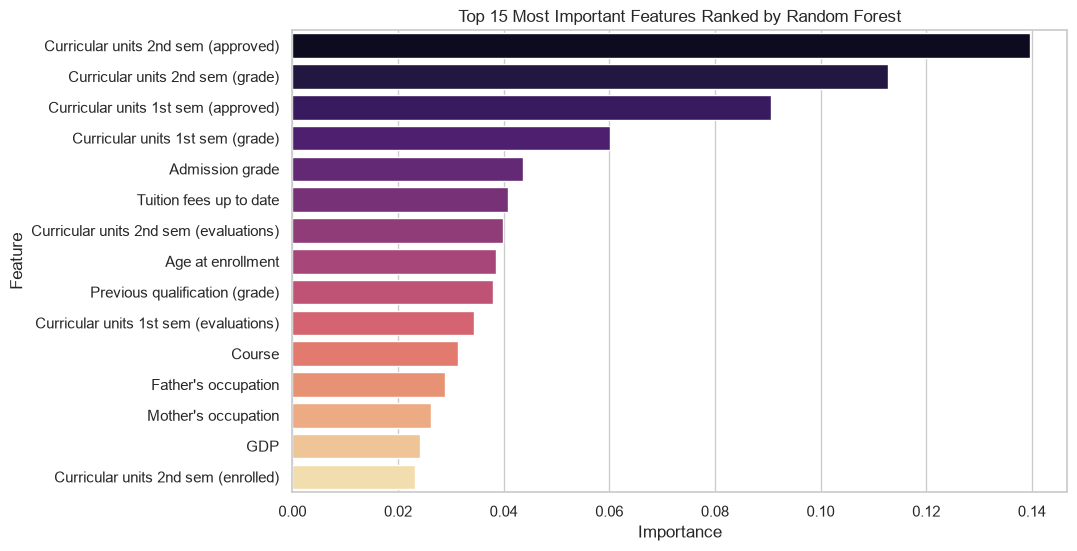

In [16]:
X_all = df_encoded.drop(columns=[target_col])
y_all = df_encoded[target_col]

rf = RandomForestClassifier(random_state=42, n_estimators=100)
rf.fit(X_all, y_all)

importance_df = pd.DataFrame({
    "Feature": X_all.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x="Importance", y="Feature", palette="magma")
plt.title("Top 15 Most Important Features Ranked by Random Forest")
plt.show()

In [17]:
# Extract the VIP features dynamically to prioritize for deep-dive plotting
vip_features = importance_df["Feature"].tolist()
vip_numerical = [col for col in vip_features if col in numerical_cols][:6]
vip_categorical = [col for col in vip_features if col in categorical_cols][:6]

4. Univariate Analysis (Targeted Deep-Dive)
*Now we look down the specific avenues our mathematical scouts discovered.*

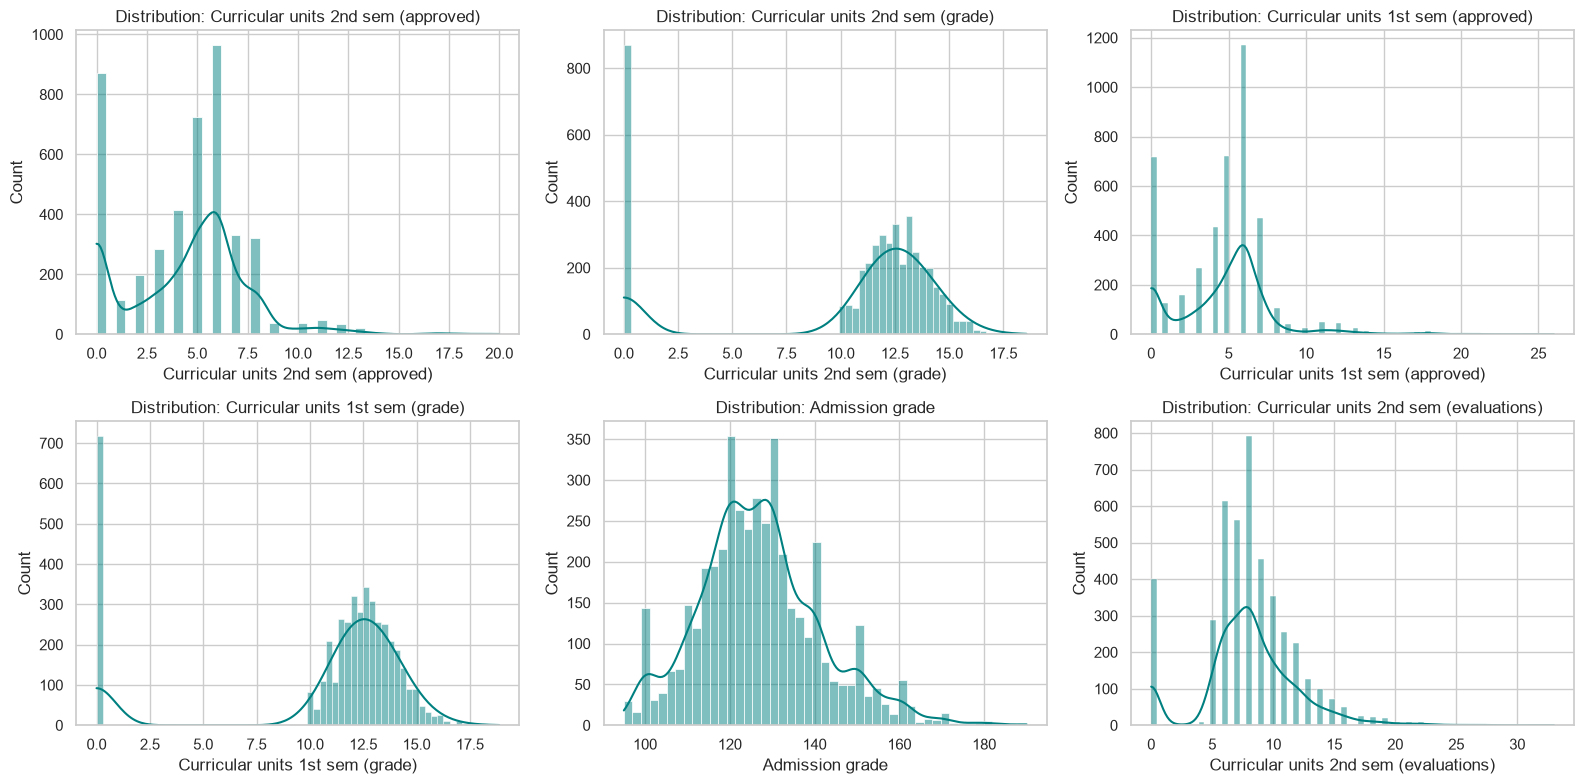

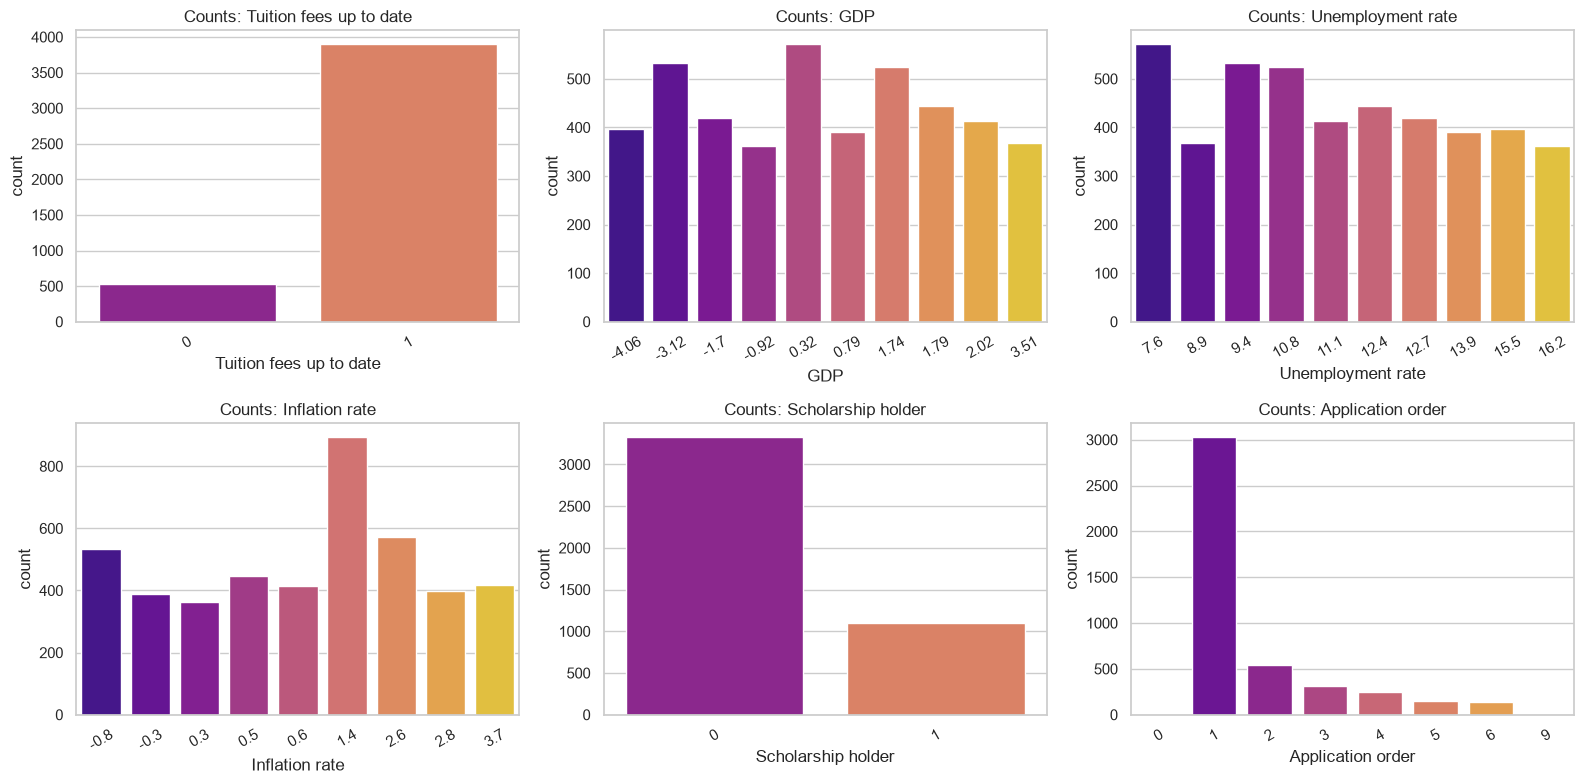

In [18]:
# Visualizing top high-impact numerical feature distributions
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(vip_numerical):
    sns.histplot(df[col], kde=True, ax=axes[i], color="teal")
    axes[i].set_title(f"Distribution: {col}")
plt.tight_layout()
plt.show()

# Visualizing top high-impact categorical feature counts
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(vip_categorical):
    sns.countplot(data=df, x=col, ax=axes[i], palette="plasma")
    axes[i].set_title(f"Counts: {col}")
    axes[i].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

5. Bivariate Analysis (Targeted Deep-Dive)

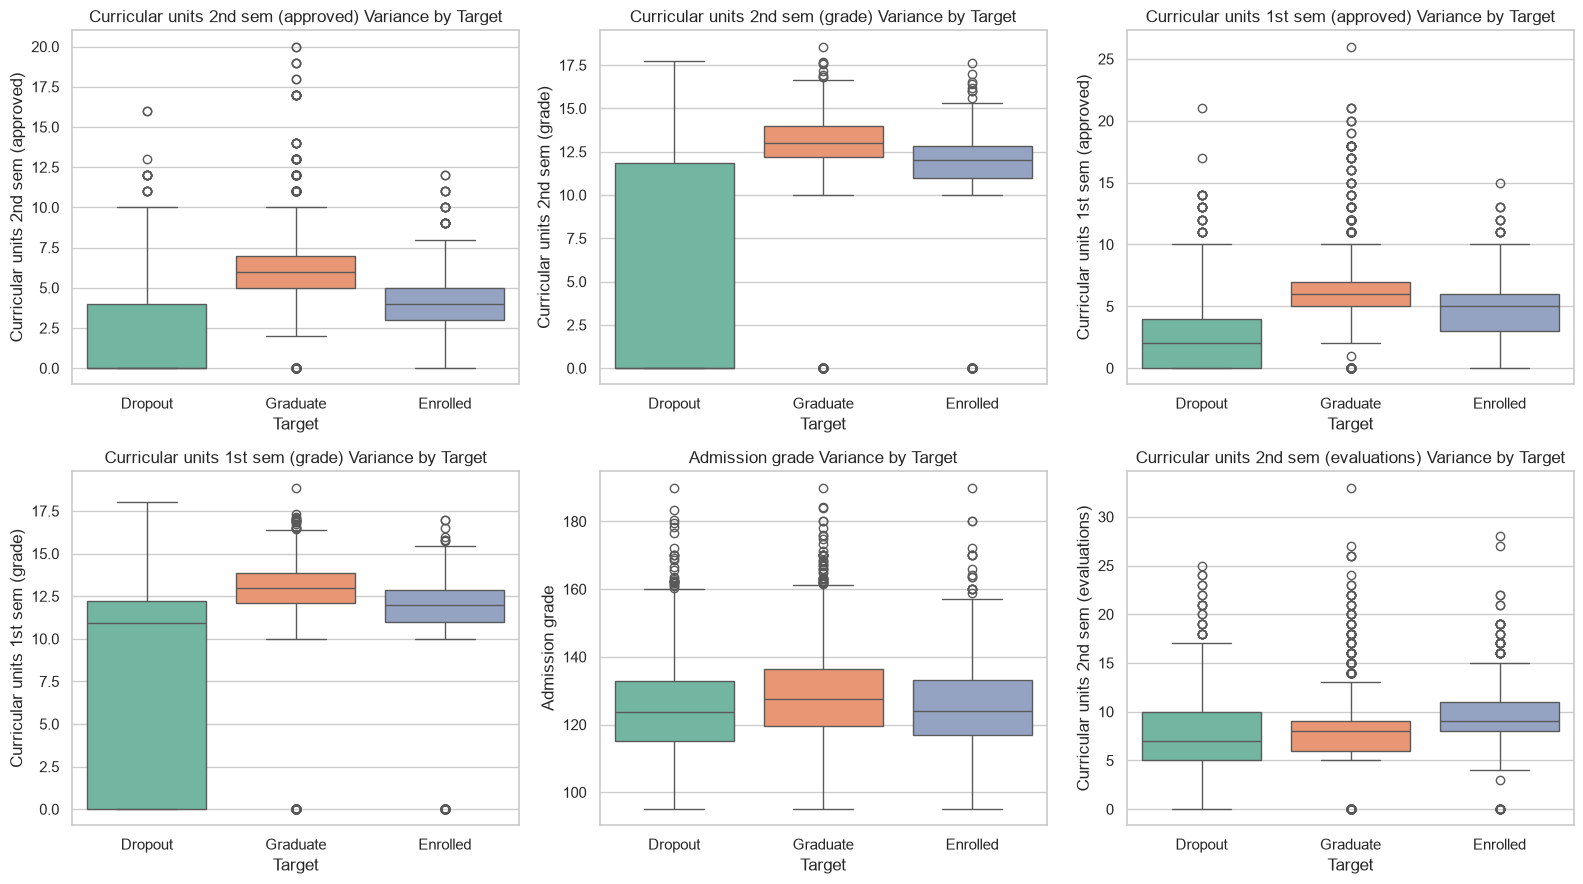

In [78]:
# 5.1 Numerical vs Target

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(vip_numerical):
    sns.boxplot(data=df, x=target_col, y=col, ax=axes[i], palette="Set2")
    axes[i].set_title(f"{col} Variance by Target")
plt.tight_layout()
plt.show()

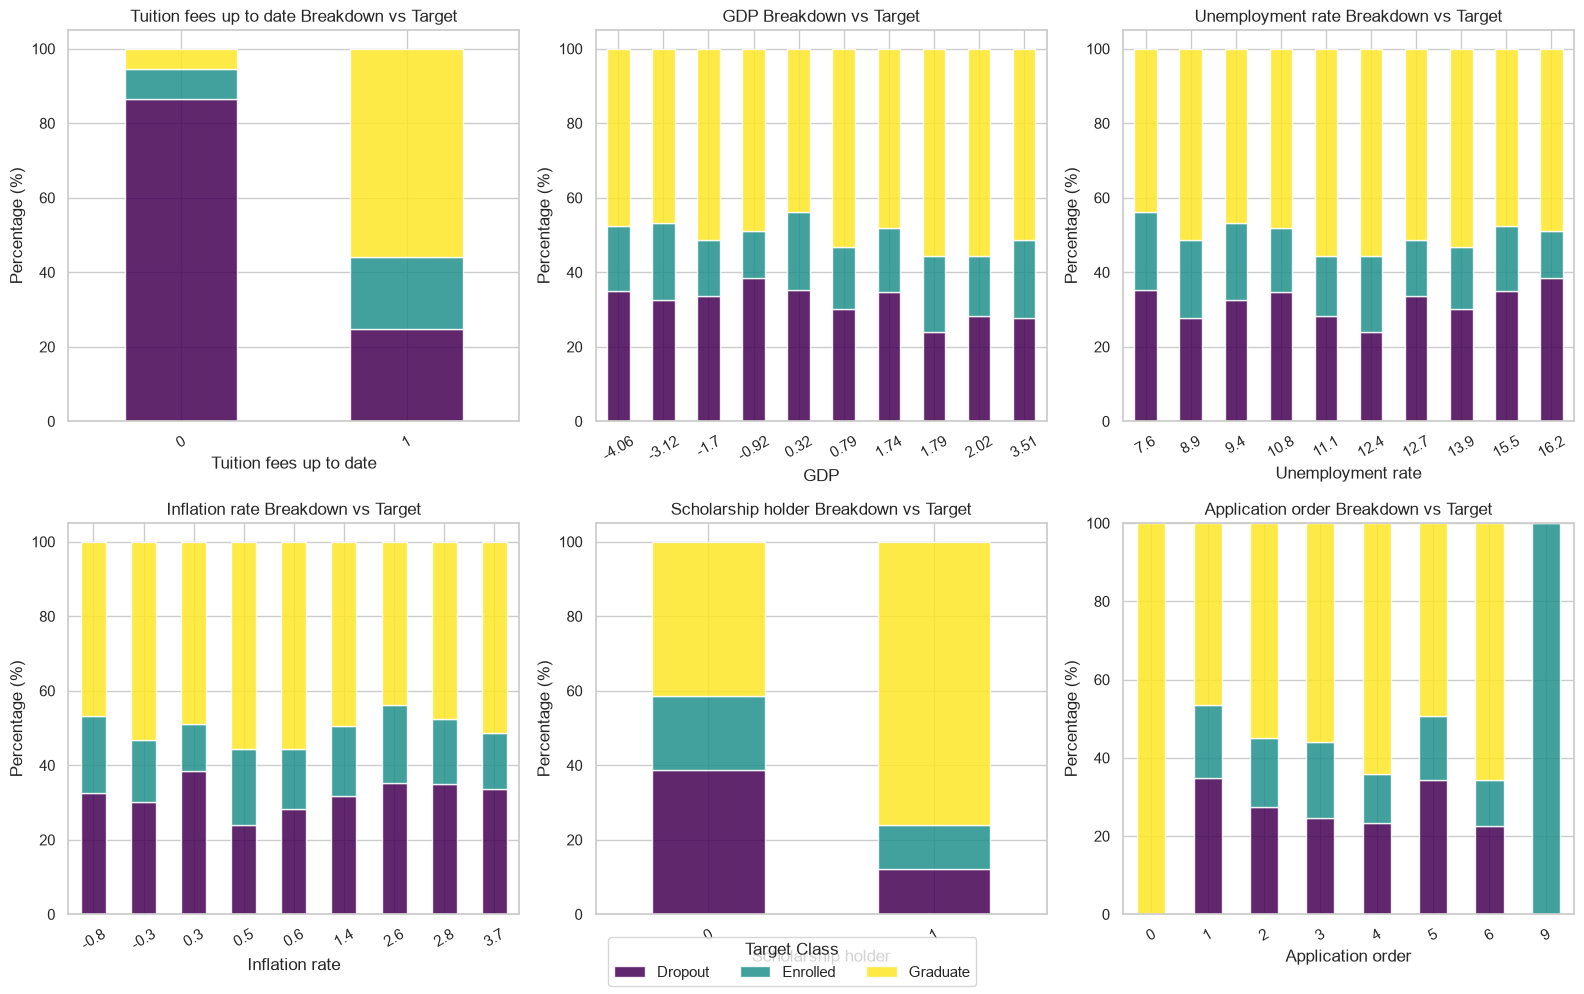

In [19]:
# 5.2 Categorical vs Target

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(vip_categorical):
    # Normalized proportion matrix layout to bypass count imbalances
    props = df.groupby(col)[target_col].value_counts(normalize=True).unstack() * 100
    props.plot(kind="bar", stacked=True, ax=axes[i], cmap="viridis", alpha=0.85)
    axes[i].set_title(f"{col} Breakdown vs Target")
    axes[i].set_ylabel("Percentage (%)")
    axes[i].tick_params(axis="x", rotation=30)
    axes[i].legend().remove()
    
# Add single unified legend element
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, title="Target Class")
plt.tight_layout()
plt.show()

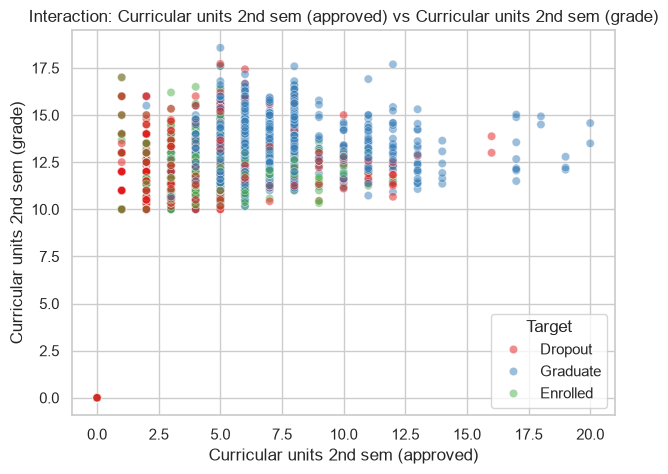

In [20]:
# 5.3 Numerical vs Numerical
# Plot interactions between the two strongest numerical predictors (e.g., 1st vs 2nd sem academic results)
if len(vip_numerical) >= 2:
    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=df, x=vip_numerical[0], y=vip_numerical[1], hue=target_col, alpha=0.5, palette="Set1")
    plt.title(f"Interaction: {vip_numerical[0]} vs {vip_numerical[1]}")
    plt.show()

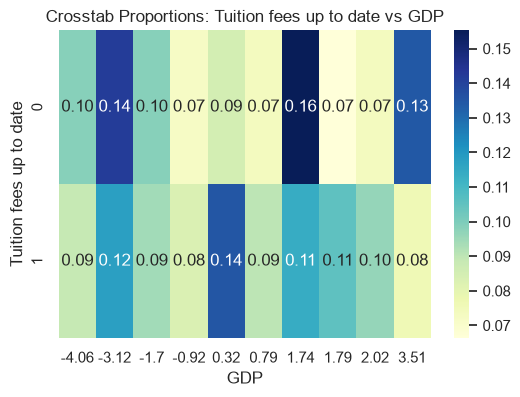

In [21]:
# 5.4 Categorical vs Categorical

if len(vip_categorical) >= 2:
    plt.figure(figsize=(6, 4))
    sns.heatmap(pd.crosstab(df[vip_categorical[0]], df[vip_categorical[1]], normalize="index"), annot=True, cmap="YlGnBu", fmt=".2f")
    plt.title(f"Crosstab Proportions: {vip_categorical[0]} vs {vip_categorical[1]}")
    plt.show()

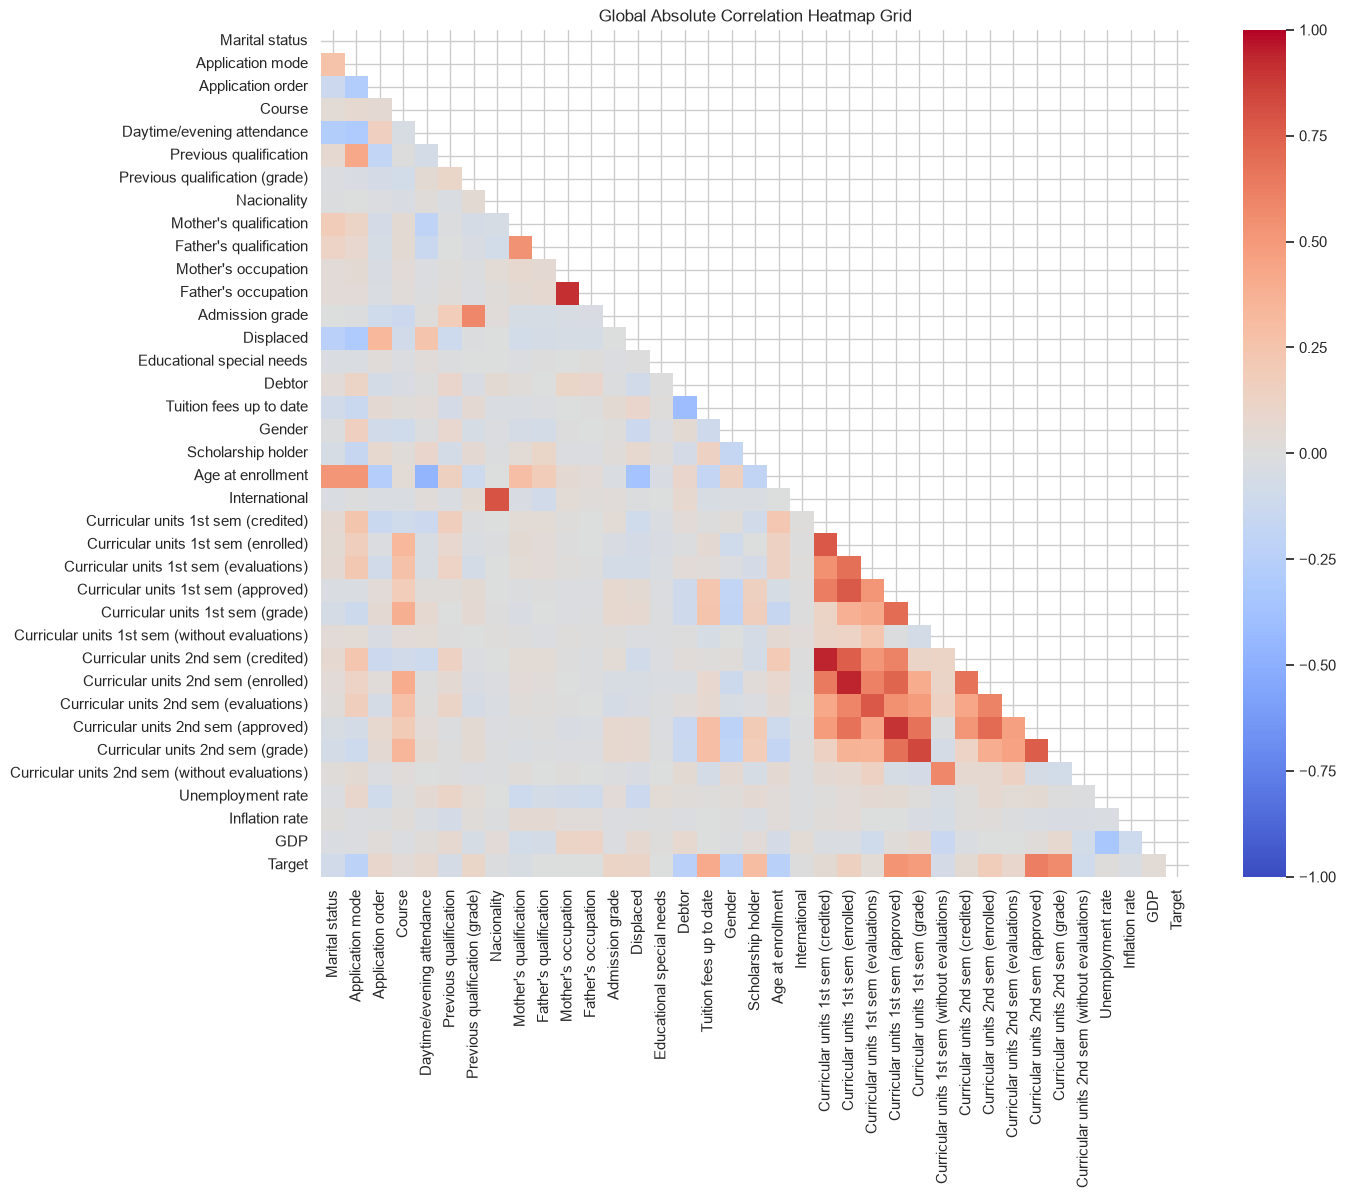

In [22]:
# 6. Correlation Analysis (Global Screen)

plt.figure(figsize=(14, 11))
corr_matrix = df_encoded.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap="coolwarm", vmin=-1, vmax=1, annot=False)
plt.title("Global Absolute Correlation Heatmap Grid")
plt.show()

7. Multicollinearity Analysis (VIF Diagnostics)

In [23]:
X_vif = df_encoded.drop(columns=[target_col]).select_dtypes(include=[np.number])
X_vif["intercept"] = 1  # Standard constant intercept baseline 

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_data = vif_data[vif_data["Feature"] != "intercept"].sort_values(by="VIF", ascending=False)

print("Features displaying High Multicollinearity warning metrics (VIF > 5):")
display(vif_data[vif_data["VIF"] > 5])

Features displaying High Multicollinearity warning metrics (VIF > 5):


,Feature,VIF
22,Curricular units 1st sem (enrolled),24.482511
28,Curricular units 2nd sem (enrolled),17.207212
21,Curricular units 1st sem (credited),16.223547
24,Curricular units 1st sem (approved),13.103872
27,Curricular units 2nd sem (credited),12.591785
30,Curricular units 2nd sem (approved),10.736544
10,Mother's occupation,5.979421
11,Father's occupation,5.970843
31,Curricular units 2nd sem (grade),5.778227
25,Curricular units 1st sem (grade),5.197275


9. Outlier Analysis

In [24]:
outlier_summary = {}
for col in vip_numerical:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    outlier_summary[col] = [outliers, round((outliers / len(df)) * 100, 2)]

outlier_df = pd.DataFrame.from_dict(outlier_summary, orient="index", columns=["Outlier Count", "Percentage (%)"])
print("Outlier Assessment Matrix for VIP Predictors:")
display(outlier_df.sort_values(by="Outlier Count", ascending=False))

Outlier Assessment Matrix for VIP Predictors:


,Outlier Count,Percentage (%)
Curricular units 2nd sem (grade),877,19.82
Curricular units 1st sem (grade),726,16.41
Curricular units 1st sem (approved),180,4.07
Curricular units 2nd sem (evaluations),109,2.46
Admission grade,86,1.94
Curricular units 2nd sem (approved),44,0.99


11. Feature Distribution Analysis (Skewness & Kurtosis)

In [25]:
dist_metrics = []
for col in numerical_cols:
    dist_metrics.append({"Feature": col, "Skewness": df[col].skew(), "Kurtosis": df[col].kurt()})

dist_df = pd.DataFrame(dist_metrics).sort_values(by="Skewness", key=abs, ascending=False)
print("Distribution Shape and Asymmetry Evaluations:")
display(dist_df.head(10))

Distribution Shape and Asymmetry Evaluations:


,Feature,Skewness,Kurtosis
4,Nacionality,10.703998,135.146206
16,Curricular units 1st sem (without evaluations),8.207403,89.863208
8,Father's occupation,5.395173,29.927395
7,Mother's occupation,5.339227,29.226145
17,Curricular units 2nd sem (credited),4.634820,24.427266
11,Curricular units 1st sem (credited),4.169049,19.205727
1,Course,-3.809135,13.199149
2,Previous qualification,2.871207,6.778166
10,Age at enrollment,2.054988,4.126892
12,Curricular units 1st sem (enrolled),1.619041,8.937915


In [86]:
#12. Cardinality Analysis

cardinality = df[categorical_cols].nunique().sort_values(ascending=False).to_frame(name="Unique Values")
print("Categorical Feature Unique Entry Count Breakdown:")
display(cardinality)

Categorical Feature Unique Entry Count Breakdown:


,Unique Values
GDP,10
Unemployment rate,10
Curricular units 2nd sem (without evaluations),10
Inflation rate,9
Application order,8
Marital status,6
Debtor,2
Educational special needs,2
Displaced,2
Daytime/evening attendance,2


In [26]:
# 13. Data Leakage Analysis (Mutual Information Check)

mi_scores = mutual_info_classif(X_all, y_all, random_state=42)
mi_df = pd.DataFrame({"Feature": X_all.columns, "Mutual Information": mi_scores}).sort_values(by="Mutual Information", ascending=False)

print("Mutual Information Profile (Flags any items approaching suspicious 1.0 threshold boundaries):")
display(mi_df.head(10))

Mutual Information Profile (Flags any items approaching suspicious 1.0 threshold boundaries):


,Feature,Mutual Information
30,Curricular units 2nd sem (approved),0.310207
31,Curricular units 2nd sem (grade),0.239324
24,Curricular units 1st sem (approved),0.233439
25,Curricular units 1st sem (grade),0.184882
16,Tuition fees up to date,0.100460
29,Curricular units 2nd sem (evaluations),0.096761
23,Curricular units 1st sem (evaluations),0.075691
19,Age at enrollment,0.065516
3,Course,0.053425
22,Curricular units 1st sem (enrolled),0.052744


In [27]:
# 14. Feature Selection Analysis (The Final Trim)

# Isolate collinear variables identified in Step 7 and weak predictors identified in Step 13
high_vif_features = vif_data[vif_data["VIF"] > 10]["Feature"].tolist()
low_mi_features = mi_df[mi_df["Mutual Information"] < 0.01]["Feature"].tolist()

# FIX VERIFIED: Standardized capitalization across columns ("Feature" matches step 10 & 13 frames)
features_to_drop = list(set(low_mi_features + [f for f in high_vif_features if "1st sem" in f]))
selected_features = [col for col in X_all.columns if col not in features_to_drop]

print(f"Suggested Dropped/Pruned Features ({len(features_to_drop)}): {features_to_drop}")
print(f"\nFinal Optimized Feature Set Size for ML Modeling Pipeline: {len(selected_features)}")
print(f"Selected Attributes: {selected_features}")

Suggested Dropped/Pruned Features (13): ['Curricular units 1st sem (enrolled)', 'Educational special needs', 'Curricular units 1st sem (without evaluations)', 'GDP', 'Curricular units 1st sem (credited)', 'Nacionality', 'Curricular units 2nd sem (credited)', 'International', 'Displaced', 'Curricular units 2nd sem (without evaluations)', 'Curricular units 1st sem (approved)', 'Unemployment rate', 'Daytime/evening attendance']

Final Optimized Feature Set Size for ML Modeling Pipeline: 23
Selected Attributes: ['Marital status', 'Application mode', 'Application order', 'Course', 'Previous qualification', 'Previous qualification (grade)', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (grade)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evalua